In [ ]:
!pip install torch transformers pandas
!pip install Keras-Preprocessing
!pip install datasets

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix
import os
os.environ["OMP_NUM_THREADS"] = "1" # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "1" # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "1" # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" # export VECLIB_MAXIMUM_THREADS=1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 200]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6150 entries, 524 to 61819
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            6150 non-null   object 
 1   country                             6150 non-null   object 
 2   contest_url                         6150 non-null   object 
 3   num_of_contest                      6150 non-null   int64  
 4   is_weekly                           6150 non-null   bool   
 5   rank                                6150 non-null   int64  
 6   score                               6150 non-null   int64  
 7   question_number                     6150 non-null   int64  
 8   question_language                   6150 non-null   object 
 9   question_code                       6150 non-null   object 
 10  number_of_lines                     6150 non-null   int64  
 11  names_set                           6150 non-

In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, y_train, test_size=0.125, random_state=0,stratify=y_train)

In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

5

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "microsoft/graphcodebert-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=8,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=5e-5,
    save_total_limit=2,
    metric_for_best_model='f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,
    early_stopping_threshold=0.01
)

In [ ]:
from datasets import load_metric

# Initialize the metric
metric = load_metric("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    f1 = f1_score(p.label_ids, preds, average='macro')  # Use weighted average for multiclass classification
    return {"f1": f1}

<ipython-input-16-20a411cf407c>:4: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  metric = load_metric("f1")


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,1.078800,1.065508,0.341282
2,0.947600,0.897948,0.383644
3,0.755400,0.911323,0.534887
4,0.724900,0.753911,0.583820
5,0.527200,0.656443,0.634004
6,0.316400,0.628703,0.704884
7,0.222100,0.659457,0.711463
8,0.092900,0.687423,0.713061


TrainOutput(global_step=1080, training_loss=0.6229635411390552, metrics={'train_runtime': 1890.0495, 'train_samples_per_second': 18.222, 'train_steps_per_second': 0.571, 'total_flos': 9061788826460160.0, 'train_loss': 0.6229635411390552, 'epoch': 8.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_pred += predictions.tolist()

               precision    recall  f1-score   support

       Canada       0.60      0.79      0.69        77
        China       0.65      0.67      0.66        75
        India       0.89      0.87      0.88       695
        Japan       0.67      0.62      0.65        48
United States       0.75      0.74      0.75       335

     accuracy                           0.81      1230
    macro avg       0.71      0.74      0.72      1230
 weighted avg       0.81      0.81      0.81      1230

f1_score :  0.808949583606124


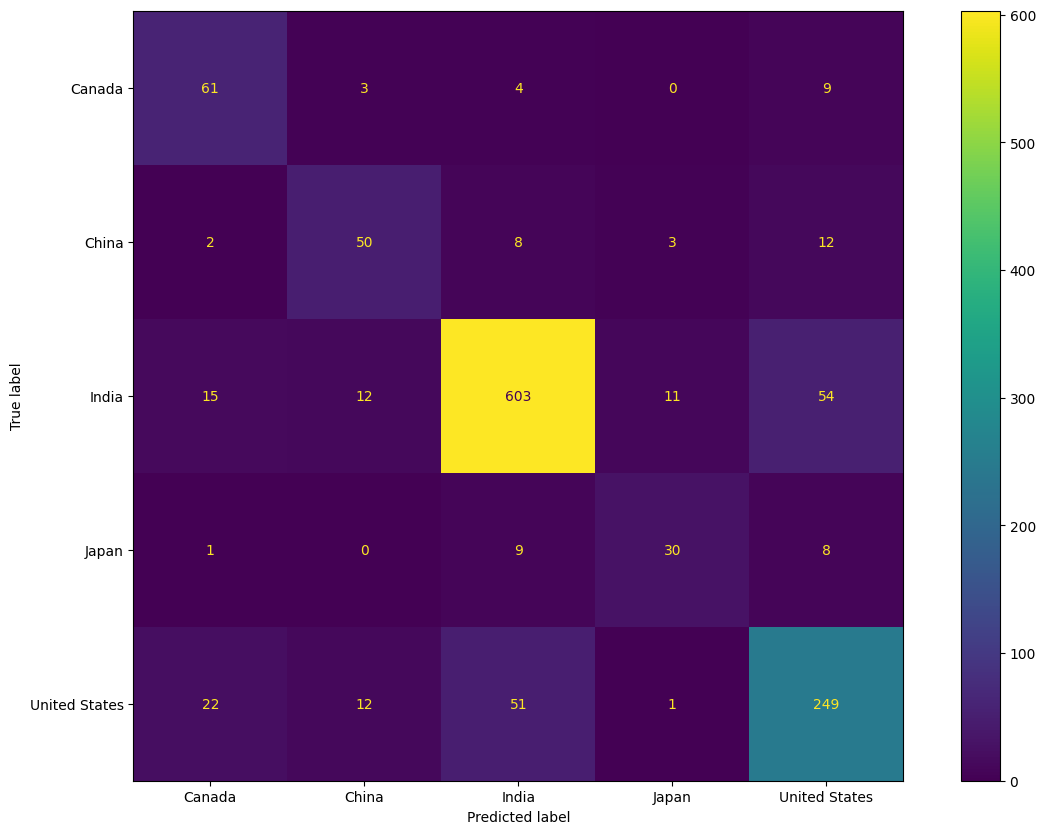

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_pred, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_pred += predictions.tolist()

               precision    recall  f1-score   support

       Canada       0.96      0.96      0.96       272
        China       0.95      0.98      0.96       262
        India       0.99      0.99      0.99      2433
        Japan       0.92      0.95      0.93       166
United States       0.99      0.98      0.99      1172

     accuracy                           0.98      4305
    macro avg       0.96      0.97      0.97      4305
 weighted avg       0.98      0.98      0.98      4305

f1_score :  0.9833369072547558


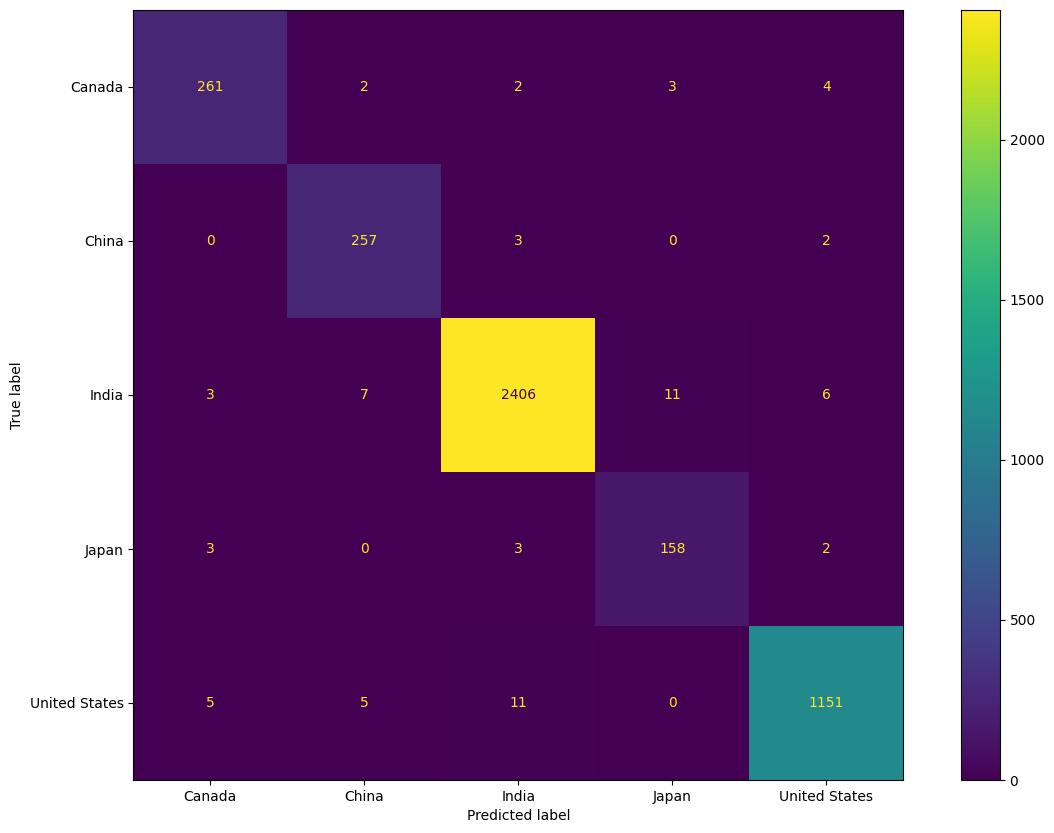

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()